# Data Understanding: Open Transaction Data
**3.4.2 Data Understanding**

This notebook performs a comprehensive data understanding analysis on the **Open Transaction Data** dataset, covering property transaction records in Malaysia from 2021 to 2025. The analysis includes variable description, observation summaries, distribution visualizations, and key insights.

## 1. Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

In [2]:
# Load dataset
file_path = '../property data/Open Transaction Data.xlsx'

# ensure path exists
import os
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Data file not found: {file_path}")
df_raw = pd.read_excel(file_path)

print(f'Dataset loaded successfully.')
print(f'Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')

Dataset loaded successfully.
Shape: 401,597 rows x 11 columns


## 2. Initial Inspection

In [3]:
print('=== Column Names ===')
for i, col in enumerate(df_raw.columns):
    print(f'  [{i}] {repr(col)}')

print('\n=== First 5 Rows ===')
df_raw.head()

=== Column Names ===
  [0] 'Property Type'
  [1] 'District'
  [2] 'Mukim'
  [3] 'Scheme Name/Area'
  [4] 'Road Name'
  [5] 'Month, Year of Transaction Date'
  [6] 'Tenure'
  [7] 'Land/Parcel Area (sqm)'
  [8] 'Main Floor Area (sqm)'
  [9] 'Unit Level'
  [10] 'Transaction Price  '

=== First 5 Rows ===


,Property Type,District,Mukim,Scheme Name/Area,Road Name,"Month, Year of Transaction Date",Tenure,Land/Parcel Area (sqm),Main Floor Area (sqm),Unit Level,Transaction Price
0,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Bdr Masjid Tanah,TMN BUKIT INDAH FASA 2,JLN BUKIT INDAH 6,2024-03-01,Freehold,374.0,106,,"RM470,000.00"
1,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN BELIMBING HARMONI,JLN BELIMBING HARMONI,2023-05-01,Leasehold,234.0,67,,"RM483,000.00"
2,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,268.0,118,,"RM359,000.00"
3,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,268.0,118,,"RM435,000.00"
4,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,297.0,118,,"RM373,000.00"


In [4]:
print('=== Data Types ===')
print(df_raw.dtypes)
print('\n=== Basic Info ===')
df_raw.info()

=== Data Types ===
Property Type                              object
District                                   object
Mukim                                      object
Scheme Name/Area                           object
Road Name                                  object
Month, Year of Transaction Date    datetime64[ns]
Tenure                                     object
Land/Parcel Area (sqm)                    float64
Main Floor Area (sqm)                      object
Unit Level                                 object
Transaction Price                          object
dtype: object

=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401597 entries, 0 to 401596
Data columns (total 11 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   Property Type                    401597 non-null  object        
 1   District                         401597 non-null  object        
 2   M

## 3. Data Preprocessing (for Understanding)

Section 3 is where we get the raw spreadsheet into a form that’s usable for the
rest of the notebook.  
In prose it does the following:

* make a working copy of `df_raw` so the original stays untouched,
* rename awkward column labels (`'Transaction Price  '` → `'Transaction Price'`,
    `'Month, Year of Transaction Date'` → `'Transaction Date'`),
* clean and convert the price field – strip “RM” and commas and cast to float in
    a new `Transaction Price (RM)` column,
* parse the transaction date string into a `datetime` and pull out `Year` and
    `Month`,
* coerce the “Main Floor Area” column to numeric (non‑numeric entries become
    NaN),
* finally, report the shape of the cleaned dataframe.

These preprocessing steps ensure the dataset has consistent names and
appropriate dtypes (numerical prices/areas, datetime dates, etc.) so that
subsequent exploration, summaries and plots work correctly.

In [5]:
# Work on a clean copy
df = df_raw.copy()

In [6]:
# Rename columns for ease of use
df.rename(columns={
    'Transaction Price  ': 'Transaction Price',
    'Month, Year of Transaction Date': 'Transaction Date'
}, inplace=True)


In [7]:

# Parse Transaction Price: strip 'RM' and commas -> float
df['Transaction Price (RM)'] = (
    df['Transaction Price']
    .str.replace('RM', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)

In [8]:

# Parse date
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
df['Year'] = df['Transaction Date'].dt.year
df['Month'] = df['Transaction Date'].dt.month


In [9]:

# Coerce Main Floor Area to numeric
df['Main Floor Area (sqm)'] = pd.to_numeric(df['Main Floor Area (sqm)'], errors='coerce')


In [10]:

print('Preprocessing complete.')
print(f'Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

Preprocessing complete.
Final shape: 401,597 rows x 14 columns


---
## 4. Variables – Description of Each Variable

The table below describes all 11 original variables in the dataset.

In [11]:
variable_info = pd.DataFrame({
    'Variable': [
        'Property Type',
        'District',
        'Mukim',
        'Scheme Name/Area',
        'Road Name',
        'Month, Year of Transaction Date',
        'Tenure',
        'Land/Parcel Area (sqm)',
        'Main Floor Area (sqm)',
        'Unit Level',
        'Transaction Price'
    ],
    'Data Type': [
        'Categorical (Nominal)',
        'Categorical (Nominal)',
        'Categorical (Nominal)',
        'Categorical (Nominal)',
        'Categorical (Nominal)',
        'Datetime',
        'Categorical (Binary)',
        'Numerical (Continuous)',
        'Numerical (Continuous)',
        'Categorical / Numerical',
        'Numerical (Continuous)'
    ],
    'Description': [
        'Type/category of the residential property (e.g., terraced, semi-detached, condominium)',
        'Administrative district where the property is located',
        'Sub-district (mukim) within the district',
        'Name of the housing scheme or area/neighbourhood',
        'Name of the road where the property is located',
        'Month and year in which the property transaction was recorded',
        'Ownership type: Freehold or Leasehold',
        'Total land or parcel area of the property in square metres',
        'Built-up/main floor area of the property in square metres',
        'Floor level of the unit (applicable for high-rise properties)',
        'Recorded transaction/sale price of the property in Malaysian Ringgit (RM)'
    ],
    'Role': [
        'Feature', 'Feature', 'Feature', 'Feature', 'Feature',
        'Feature', 'Feature', 'Feature', 'Feature', 'Feature',
        'Target / Feature'
    ]
})

pd.set_option('display.max_colwidth', 80)
variable_info

,Variable,Data Type,Description,Role
0,Property Type,Categorical (Nominal),"Type/category of the residential property (e.g., terraced, semi-detached, co...",Feature
1,District,Categorical (Nominal),Administrative district where the property is located,Feature
2,Mukim,Categorical (Nominal),Sub-district (mukim) within the district,Feature
3,Scheme Name/Area,Categorical (Nominal),Name of the housing scheme or area/neighbourhood,Feature
4,Road Name,Categorical (Nominal),Name of the road where the property is located,Feature
5,"Month, Year of Transaction Date",Datetime,Month and year in which the property transaction was recorded,Feature
6,Tenure,Categorical (Binary),Ownership type: Freehold or Leasehold,Feature
7,Land/Parcel Area (sqm),Numerical (Continuous),Total land or parcel area of the property in square metres,Feature
8,Main Floor Area (sqm),Numerical (Continuous),Built-up/main floor area of the property in square metres,Feature
9,Unit Level,Categorical / Numerical,Floor level of the unit (applicable for high-rise properties),Feature


In [12]:
print('=== Adjusted Data Types ===')
print(df.dtypes)
print(f'Dataset has {df.shape[1]} columns')

=== Adjusted Data Types ===
Property Type                     object
District                          object
Mukim                             object
Scheme Name/Area                  object
Road Name                         object
Transaction Date          datetime64[ns]
Tenure                            object
Land/Parcel Area (sqm)           float64
Main Floor Area (sqm)            float64
Unit Level                        object
Transaction Price                 object
Transaction Price (RM)           float64
Year                               int32
Month                              int32
dtype: object
Dataset has 14 columns


In [13]:
print('=== Data Types Raw ===')
print(df_raw.dtypes)

print(f'Dataset has {df_raw.shape[1]} columns')

=== Data Types Raw ===
Property Type                              object
District                                   object
Mukim                                      object
Scheme Name/Area                           object
Road Name                                  object
Month, Year of Transaction Date    datetime64[ns]
Tenure                                     object
Land/Parcel Area (sqm)                    float64
Main Floor Area (sqm)                      object
Unit Level                                 object
Transaction Price                          object
dtype: object
Dataset has 11 columns


In [14]:

print('=== Adjusted Data Types ===')
print(df.dtypes)
print(f'Dataset has {df.shape[1]} columns')

print('\n')
print('=== Data Types Raw ===')
print(df_raw.dtypes)

print(f'Dataset has {df_raw.shape[1]} columns')


=== Adjusted Data Types ===
Property Type                     object
District                          object
Mukim                             object
Scheme Name/Area                  object
Road Name                         object
Transaction Date          datetime64[ns]
Tenure                            object
Land/Parcel Area (sqm)           float64
Main Floor Area (sqm)            float64
Unit Level                        object
Transaction Price                 object
Transaction Price (RM)           float64
Year                               int32
Month                              int32
dtype: object
Dataset has 14 columns


=== Data Types Raw ===
Property Type                              object
District                                   object
Mukim                                      object
Scheme Name/Area                           object
Road Name                                  object
Month, Year of Transaction Date    datetime64[ns]
Tenure                              

---
## 5. Observations – Dataset Overview

In [ ]:
print('=' * 60)
print('     ADJUSTED DATASET OBSERVATION SUMMARY')
print('=' * 60)
print(f'  Total Records (Observations)  : {len(df):>10,}')
print(f'  Total Variables               : {df.shape[1]:>10}')
print(f'  Date Range                    : 2021-01 to 2025-09')
print(f'  Unique Districts              : {df["District"].nunique():>10}')
print(f'  Unique Mukims                 : {df["Mukim"].nunique():>10}')
print(f'  Unique Property Types         : {df["Property Type"].nunique():>10}')
print(f'  Freehold Transactions         : {(df["Tenure"]=="Freehold").sum():>10,}')
print(f'  Leasehold Transactions        : {(df["Tenure"]=="Leasehold").sum():>10,}')
print(f'  Min Transaction Price (RM)    : {df["Transaction Price (RM)"].min():>10,.0f}')
print(f'  Max Transaction Price (RM)    : {df["Transaction Price (RM)"].max():>10,.0f}')
print(f'  Mean Transaction Price (RM)   : {df["Transaction Price (RM)"].mean():>10,.0f}')
print(f'  Median Transaction Price (RM) : {df["Transaction Price (RM)"].median():>10,.0f}')
print('=' * 60)

     UNCLEANED BUT ADJUSTED DATASET OBSERVATION SUMMARY
  Total Records (Observations)  :    401,597
  Total Variables               :         14
  Date Range                    : 2021-01 to 2025-09
  Unique Districts              :        127
  Unique Mukims                 :       1334
  Unique Property Types         :         11
  Freehold Transactions         :    265,923
  Leasehold Transactions        :    135,674
  Min Transaction Price (RM)    :      5,000
  Max Transaction Price (RM)    : 38,000,000
  Mean Transaction Price (RM)   :    497,097
  Median Transaction Price (RM) :    370,000


### 5.1 Missing Values

In [16]:
missing = pd.DataFrame({
    'Missing Count': df_raw.isnull().sum(),
    'Missing (%)': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
# Add Main Floor Area after coerce
missing.loc['Main Floor Area (sqm) [after numeric coerce]'] = [
    df['Main Floor Area (sqm)'].isnull().sum(),
    round(df['Main Floor Area (sqm)'].isnull().sum() / len(df) * 100, 2)
]
print(missing)

                                              Missing Count  Missing (%)
Property Type                                           0.0         0.00
District                                                0.0         0.00
Mukim                                                   0.0         0.00
Scheme Name/Area                                        0.0         0.00
Road Name                                               2.0         0.00
Month, Year of Transaction Date                         0.0         0.00
Tenure                                                  0.0         0.00
Land/Parcel Area (sqm)                                  0.0         0.00
Main Floor Area (sqm)                                   0.0         0.00
Unit Level                                              0.0         0.00
Transaction Price                                       0.0         0.00
Main Floor Area (sqm) [after numeric coerce]       104191.0        25.94


Note: "Main Floor Area" has 25.9% non-numeric entries (e.g., N/A for landed properties).

### 5.2 Descriptive Statistics – Numerical Variables

In [17]:
num_cols = ['Land/Parcel Area (sqm)', 'Main Floor Area (sqm)', 'Transaction Price (RM)']
df[num_cols].describe().round(2)

,Land/Parcel Area (sqm),Main Floor Area (sqm),Transaction Price (RM)
count,401597.00,297406.00,401597.00
mean,192.27,127.45,497097.01
std,4071.72,308.19,546820.97
min,8.27,0.00,5000.00
25%,100.33,80.00,250000.00
50%,130.00,110.00,370000.00
75%,189.00,157.00,570000.00
max,1788888.00,159390.00,38000000.00


### 5.3 Descriptive Statistics – Categorical Variables

In [18]:
cat_cols = ['Property Type', 'District', 'Tenure', 'Mukim', 'Scheme Name/Area', 'Road Name']
for col in cat_cols:
    print(f'--- {col} ({df[col].nunique()} unique values) ---')
    print(df[col].value_counts().head(10).to_string())
    print()

--- Property Type (11 unique values) ---
Property Type
2 - 2 1/2 Storey Terraced         115187
1 - 1 1/2 Storey Terraced          89800
Condominium/Apartment              63523
Low-Cost House                     27253
1 - 1 1/2 Storey Semi-Detached     20931
Low-Cost Flat                      20599
Detached                           17947
2 - 2 1/2 Storey Semi-Detached     17410
Flat                               15923
Cluster House                       8878

--- District (127 unique values) ---
District
Johor Bahru     45021
Petaling        32802
Kuala Lumpur    25077
Hulu Langat     22341
Kinta           18536
Klang           18086
Seremban        16946
Gombak          12066
Timur Laut      10982
Kuala Muda      10551

--- Tenure (2 unique values) ---
Tenure
Freehold     265923
Leasehold    135674

--- Mukim (1334 unique values) ---
Mukim
Pulai                 17057
Ulu Kinta             13658
Plentong              13557
Tebrau                11500
Kelang                10618
Kuala

### 5.4 Categorical Variables – Detailed Findings

#### Property Type Distribution

The dataset contains **11 distinct property types**, with a clear market concentration in terraced housing. The 2–2½ Storey Terraced category dominates with **115,187 transactions (28.7%)**, followed closely by 1–1½ Storey Terraced at **89,800 transactions (22.4%)**. Together, terraced houses account for over half of all transactions, reflecting the popularity and affordability of this housing segment in Malaysia.

Condominiums and apartments form the second-largest market segment with **63,523 transactions (15.8%)**, indicating a significant demand for high-rise residential units, particularly in urban areas. Low-cost housing options—both houses and flats—comprise **47,852 transactions combined (11.9%)**, serving the affordable housing market segment.

Detached houses and semi-detached properties represent a more limited market share. The 1–1½ Storey Semi-Detached and 2–2½ Storey Semi-Detached categories combined account for **38,341 transactions (9.5%)**, while standalone detached houses represent just **17,947 transactions (4.5%)**. Cluster houses, the smallest category, have **8,878 transactions (2.2%)**, suggesting limited prevalence in the dataset.

#### District Distribution

The market is **geographically concentrated, with 127 unique districts** but heavily skewed toward the top performers. The **top 5 districts account for 143,777 transactions (35.8%)** of the total volume, indicating strong market concentration in key urban and semi-urban areas.

**Johor Bahru leads significantly** with **45,021 transactions (11.2%)**, the highest of any district in the dataset. This is followed by **Petaling (32,802 transactions, 8.2%)** and **Kuala Lumpur (25,077 transactions, 6.2%)**, both major business and residential hubs in the Klang Valley. The top three districts collectively account for **102,900 transactions (25.6%)** of all activity.

Secondary markets include **Hulu Langat (22,341 transactions)**, **Kinta (18,536 transactions)**, **Klang (18,086 transactions)**, and **Seremban (16,946 transactions)**, all significant urban or semi-urban centers. The remaining **117 districts** share the remainder of transactions, with most recording substantially lower activity, indicating that the Malaysian property market is dominated by a small number of high-transaction districts, likely reflecting population density and economic activity concentration.

#### Tenure Distribution

The dataset shows a **clear preference for freehold ownership**, with **265,923 freehold transactions (66.2%)** compared to **135,674 leasehold transactions (33.8%)**. This **2:1 ratio** indicates that freehold properties are nearly twice as common in the market, reflecting buyer preference for properties with full land ownership and perpetual tenure rights.

Freehold properties offer buyers indefinite ownership and greater long-term value security, making them more attractive in Malaysia's property market. In contrast, leasehold properties—which involve time-limited land rights—appeal to a more niche segment, often comprising high-rise units in urban developments where leasehold structures are standard.


---
## 6. Histograms and Visualizations
### 6.1 Distribution of Transaction Price

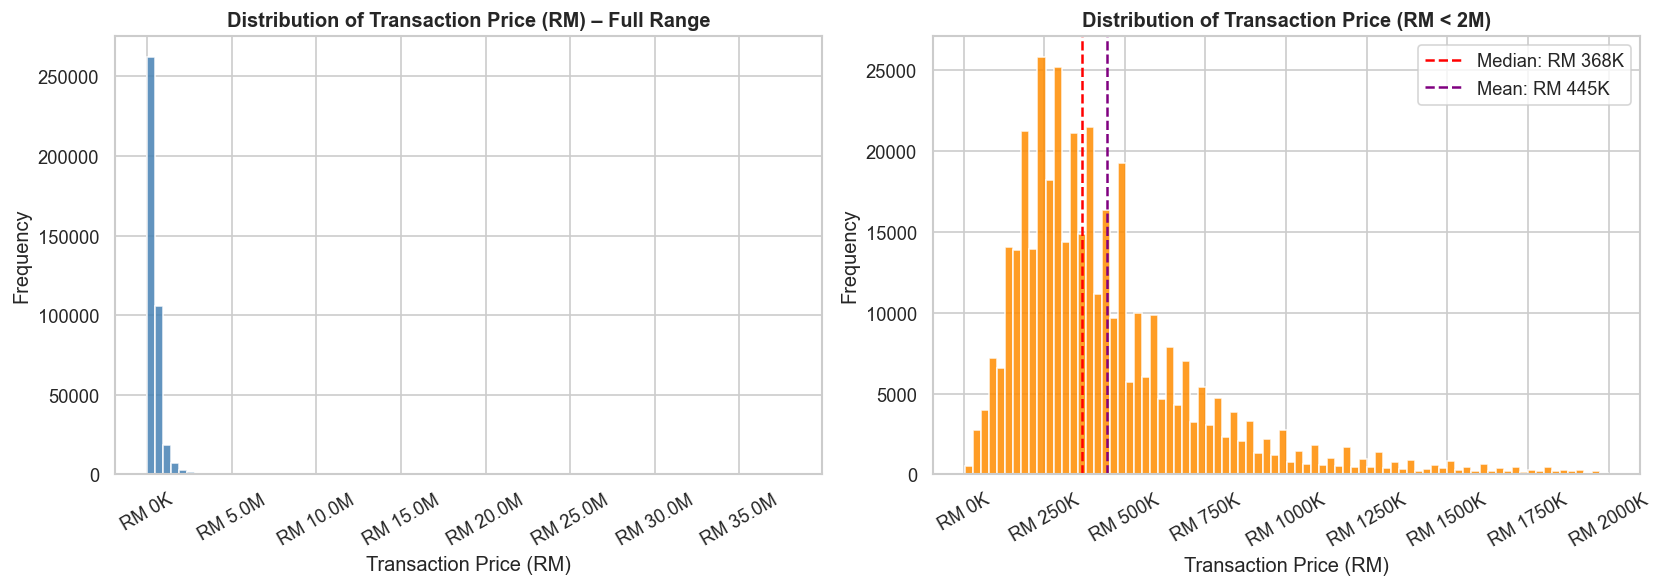

Observation: Transaction prices are right-skewed. Most transactions fall between RM 200K–600K, with a median of ~RM 370K.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(df['Transaction Price (RM)'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Transaction Price (RM) – Full Range', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Transaction Price (RM)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x/1e6:.1f}M' if x>=1e6 else f'RM {x/1e3:.0f}K'))
axes[0].tick_params(axis='x', rotation=30)

# Clipped for readability (< 2M)
clip = df[df['Transaction Price (RM)'] < 2_000_000]['Transaction Price (RM)']
axes[1].hist(clip, bins=80, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(clip.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median: RM {clip.median()/1e3:.0f}K')
axes[1].axvline(clip.mean(), color='purple', linestyle='--', linewidth=1.5, label=f'Mean: RM {clip.mean()/1e3:.0f}K')
axes[1].set_title('Distribution of Transaction Price (RM < 2M)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Transaction Price (RM)')
axes[1].set_ylabel('Frequency')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x/1e3:.0f}K'))
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.savefig('hist_transaction_price.png', bbox_inches='tight')
plt.show()
print('Observation: Transaction prices are right-skewed. Most transactions fall between RM 200K–600K, with a median of ~RM 370K.')

### 6.2 Distribution of Land/Parcel Area

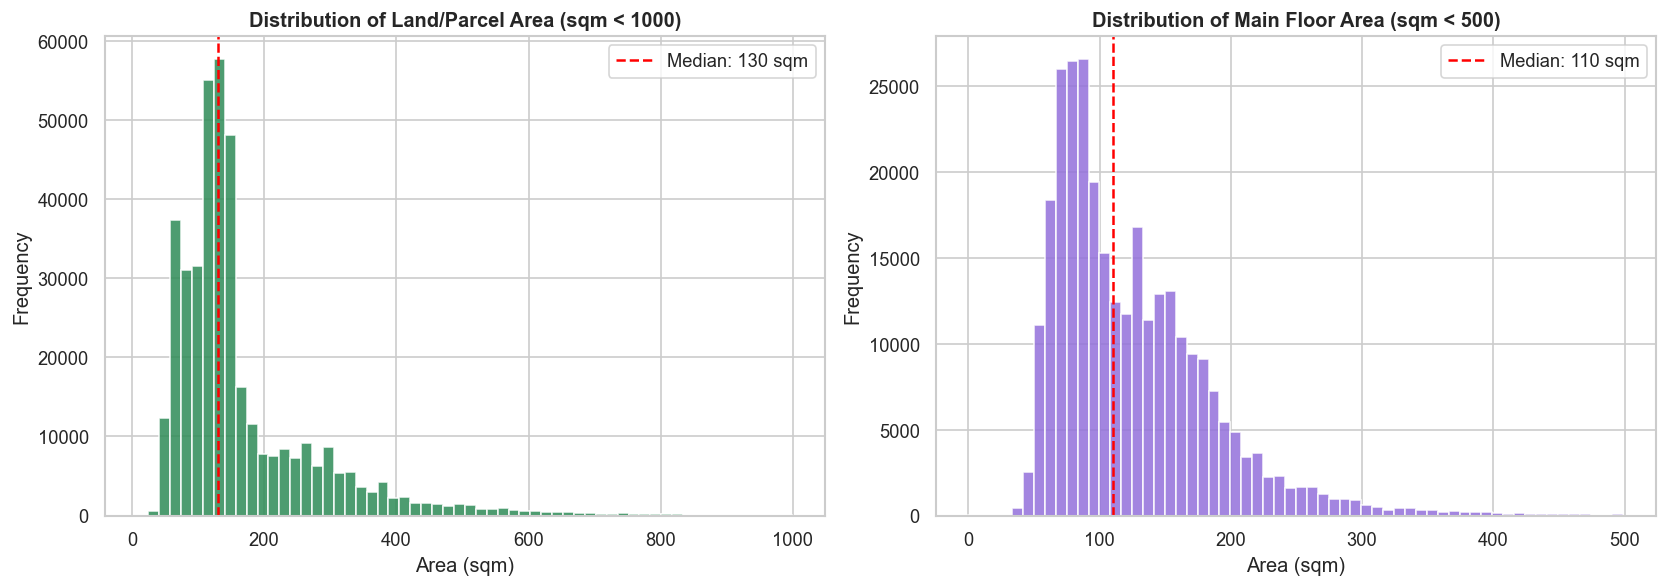

Observation: Most landed properties have parcel areas of 100–200 sqm. Main floor areas peak around 80–160 sqm.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

land_clipped = df[df['Land/Parcel Area (sqm)'] < 1000]['Land/Parcel Area (sqm)']

axes[0].hist(land_clipped, bins=60, color='seagreen', edgecolor='white', alpha=0.85)
axes[0].axvline(land_clipped.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median: {land_clipped.median():.0f} sqm')
axes[0].set_title('Distribution of Land/Parcel Area (sqm < 1000)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Area (sqm)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

floor_data = df['Main Floor Area (sqm)'].dropna()
floor_clipped = floor_data[floor_data < 500]
axes[1].hist(floor_clipped, bins=60, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[1].axvline(floor_clipped.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median: {floor_clipped.median():.0f} sqm')
axes[1].set_title('Distribution of Main Floor Area (sqm < 500)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Area (sqm)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('hist_areas.png', bbox_inches='tight')
plt.show()
print('Observation: Most landed properties have parcel areas of 100–200 sqm. Main floor areas peak around 80–160 sqm.')

### 6.3 Transactions by Property Type

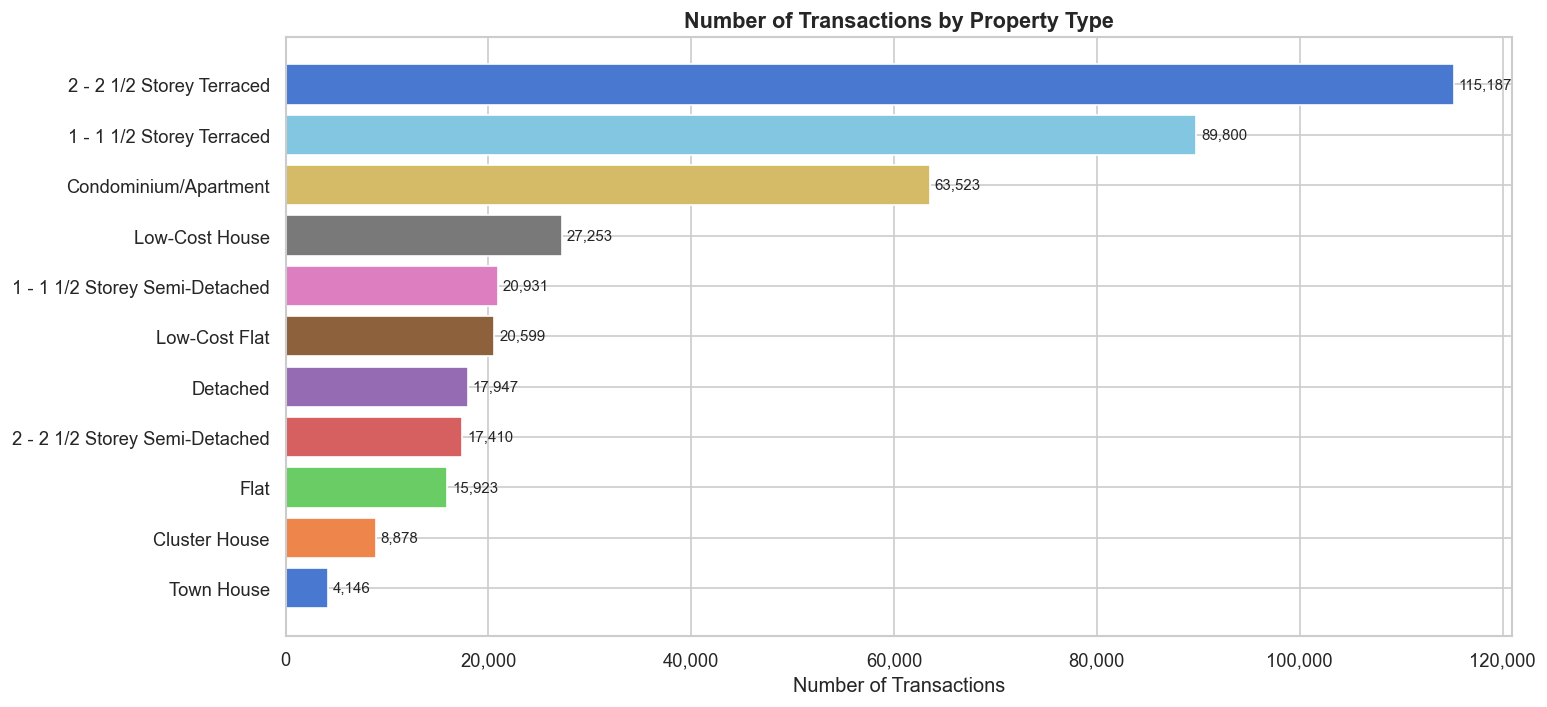

Observation: 2-2.5 Storey Terraced houses are the most transacted property type (115,187), followed by 1-1.5 Storey Terraced (89,800) and Condominiums/Apartments (63,523).


In [21]:
prop_counts = df['Property Type'].value_counts()

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(prop_counts.index[::-1], prop_counts.values[::-1], color=sns.color_palette('muted', len(prop_counts)))

for bar, val in zip(bars, prop_counts.values[::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('Number of Transactions by Property Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Transactions')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('bar_property_type.png', bbox_inches='tight')
plt.show()
print('Observation: 2-2.5 Storey Terraced houses are the most transacted property type (115,187), followed by 1-1.5 Storey Terraced (89,800) and Condominiums/Apartments (63,523).')

### 6.4 Transactions by District (Top 15)

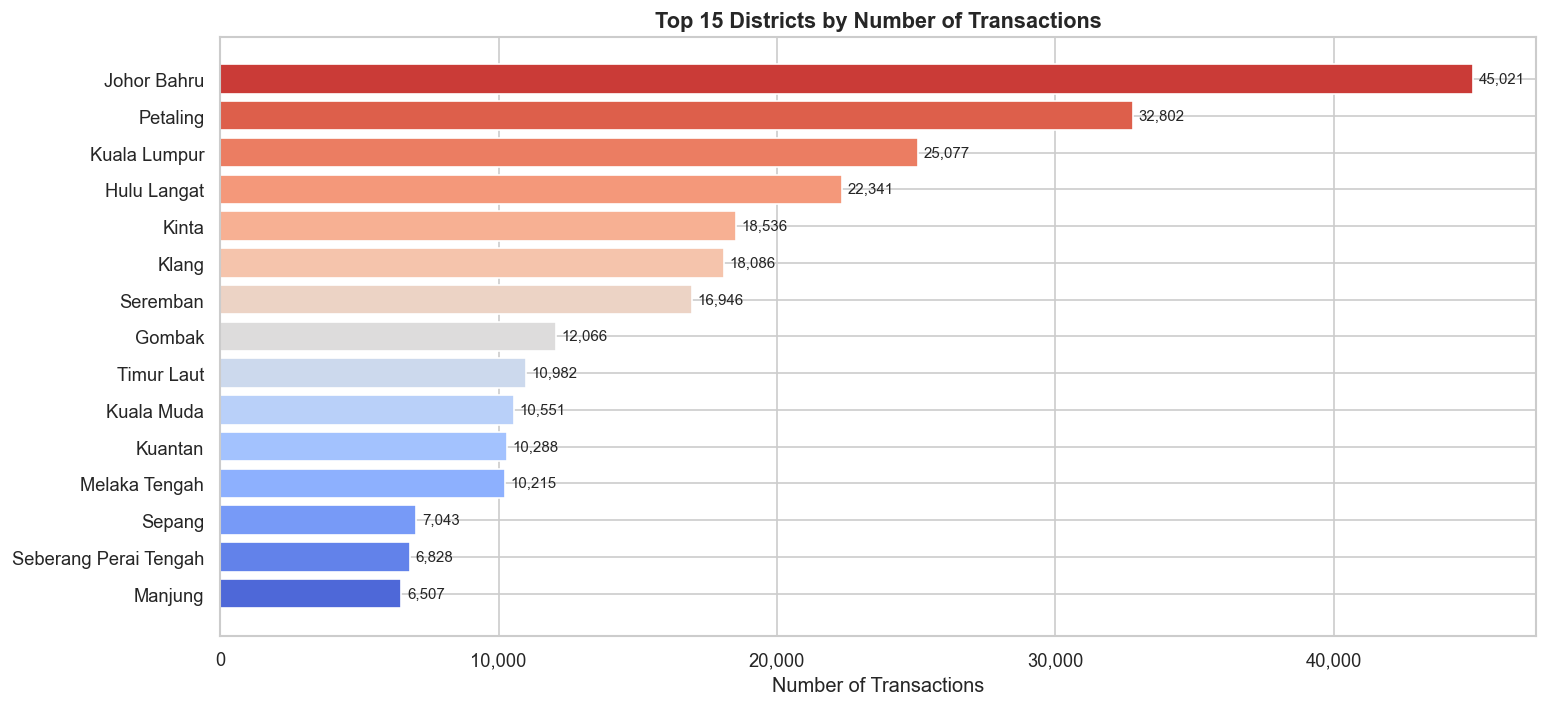

Observation: Johor Bahru leads with 45,021 transactions, followed by Petaling (32,802) and Kuala Lumpur (25,077).


In [22]:
top15 = df['District'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(13, 6))
colors = sns.color_palette('coolwarm', 15)
bars = ax.barh(top15.index[::-1], top15.values[::-1], color=colors)
for bar, val in zip(bars, top15.values[::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('Top 15 Districts by Number of Transactions', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Transactions')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('bar_district.png', bbox_inches='tight')
plt.show()
print('Observation: Johor Bahru leads with 45,021 transactions, followed by Petaling (32,802) and Kuala Lumpur (25,077).')

### 6.5 Tenure Distribution (Freehold vs Leasehold)

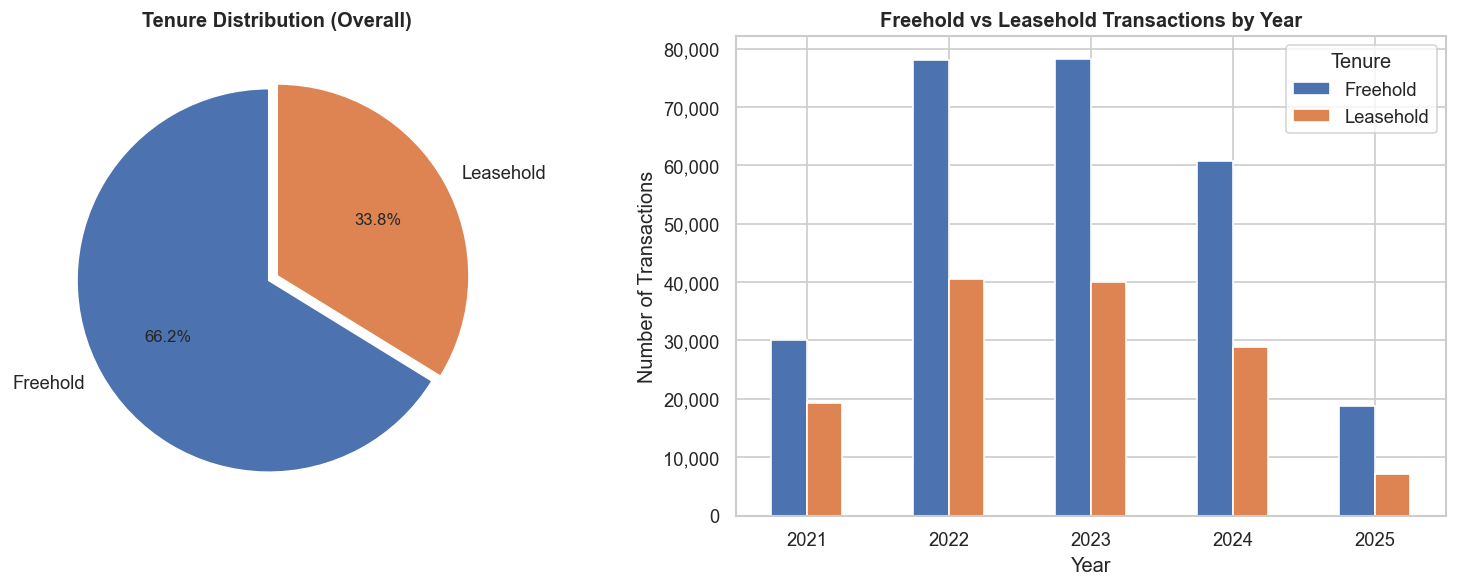

Observation: 66.2% of all transactions are Freehold properties, outnumbering Leasehold (33.8%) consistently across all years.


In [23]:
tenure_counts = df['Tenure'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
axes[0].pie(
    tenure_counts.values,
    labels=tenure_counts.index,
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452'],
    startangle=90,
    explode=(0.05, 0)
)
axes[0].set_title('Tenure Distribution (Overall)', fontsize=12, fontweight='bold')

# By year
tenure_year = df.groupby(['Year', 'Tenure']).size().unstack(fill_value=0)
tenure_year.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[1].set_title('Freehold vs Leasehold Transactions by Year', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Transactions')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Tenure')

plt.tight_layout()
plt.savefig('pie_tenure.png', bbox_inches='tight')
plt.show()
print('Observation: 66.2% of all transactions are Freehold properties, outnumbering Leasehold (33.8%) consistently across all years.')

### 6.6 Transaction Volume Over Time (Monthly Trend)

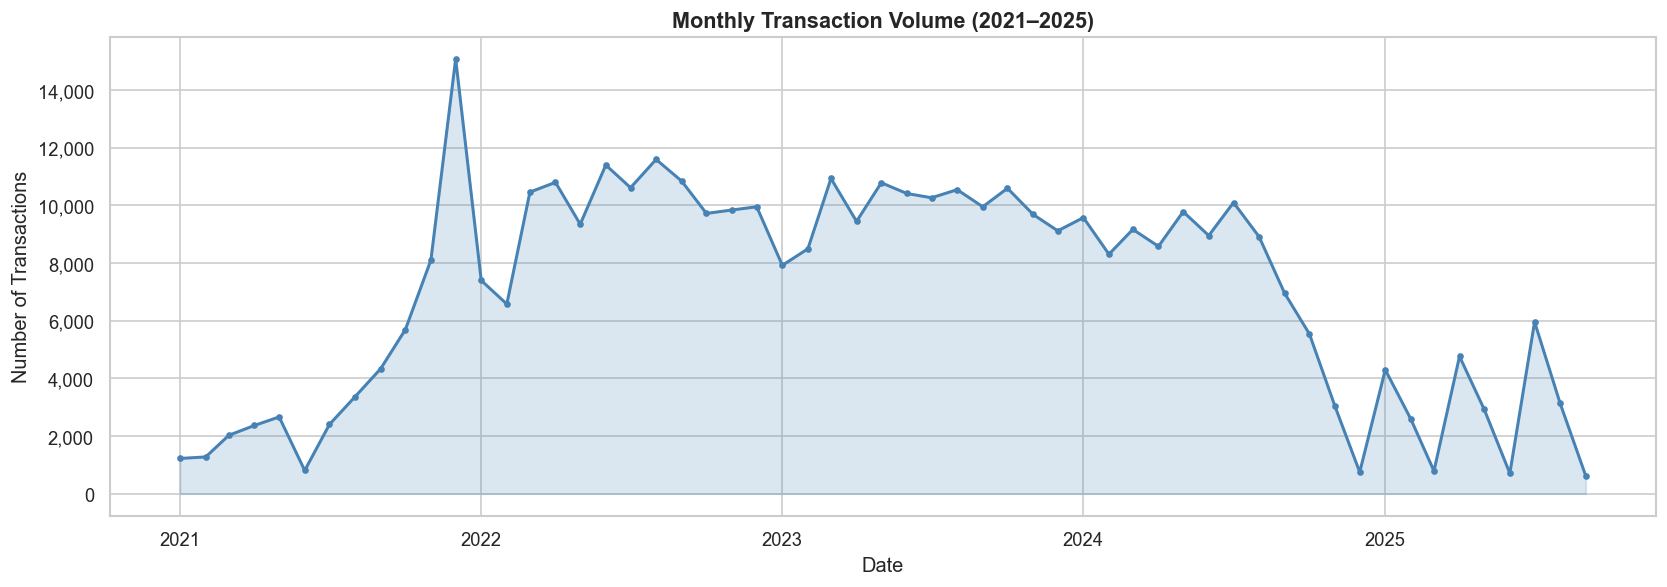

Observation: Transaction volume shows a peak around 2022-2023, with a gradual tapering in 2024-2025 (partial year data for 2025).


In [24]:
monthly = df.groupby('Transaction Date').size().reset_index(name='Count')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['Transaction Date'], monthly['Count'], color='steelblue', linewidth=1.8, marker='o', markersize=3)
ax.fill_between(monthly['Transaction Date'], monthly['Count'], alpha=0.2, color='steelblue')
ax.set_title('Monthly Transaction Volume (2021–2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Transactions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('line_monthly_volume.png', bbox_inches='tight')
plt.show()
print('Observation: Transaction volume shows a peak around 2022-2023, with a gradual tapering in 2024-2025 (partial year data for 2025).')

### 6.7 Annual Transaction Count by Year

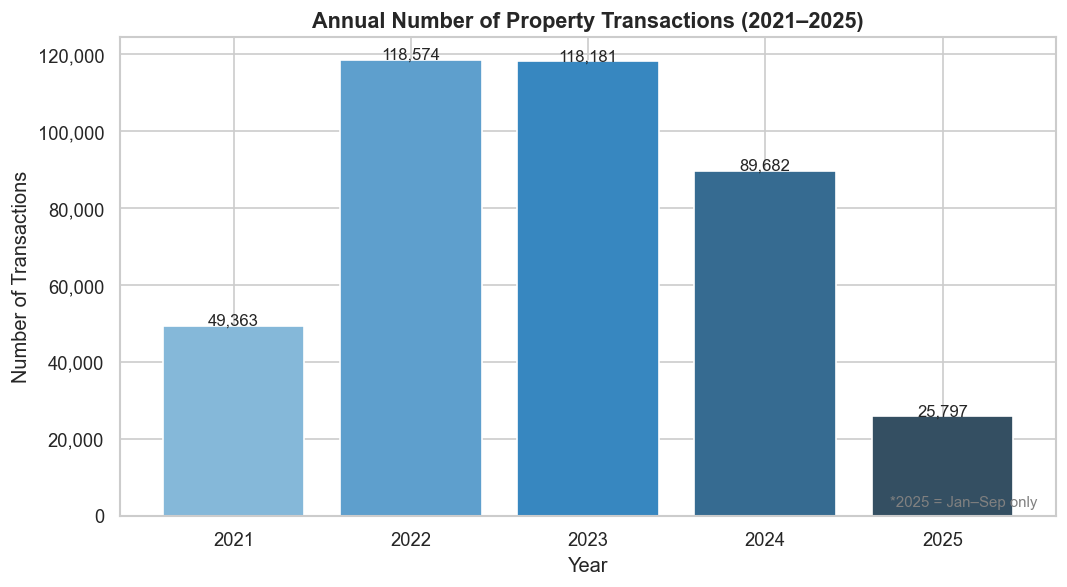

Observation: 2022 and 2023 recorded the highest volumes (~118K transactions each), indicating a post-pandemic property market rebound.


In [25]:
yearly = df['Year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(yearly.index.astype(str), yearly.values, color=sns.color_palette('Blues_d', len(yearly)), edgecolor='white')
for bar, val in zip(bars, yearly.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300, f'{val:,}', ha='center', fontsize=10)

ax.set_title('Annual Number of Property Transactions (2021–2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Transactions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.annotate('*2025 = Jan–Sep only', xy=(0.98, 0.02), xycoords='axes fraction', ha='right', fontsize=9, color='grey')
plt.tight_layout()
plt.savefig('bar_annual_volume.png', bbox_inches='tight')
plt.show()
print('Observation: 2022 and 2023 recorded the highest volumes (~118K transactions each), indicating a post-pandemic property market rebound.')

### 6.8 Median Transaction Price by Property Type

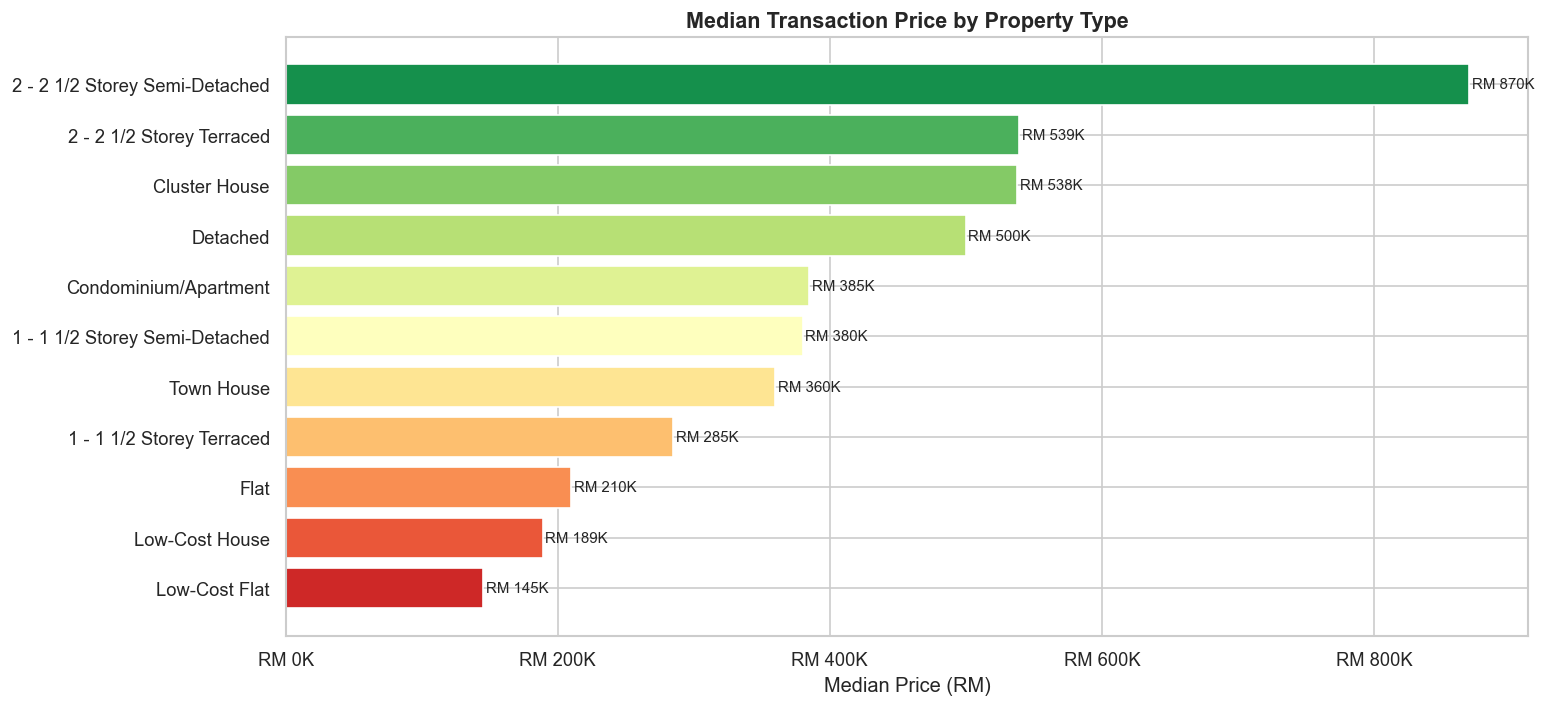

Observation: Detached houses command the highest median price, while Low-Cost Houses and Flats have the lowest median transaction prices.


In [26]:
median_price = df.groupby('Property Type')['Transaction Price (RM)'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(median_price.index[::-1], median_price.values[::-1],
               color=sns.color_palette('RdYlGn', len(median_price)))
for bar, val in zip(bars, median_price.values[::-1]):
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
            f'RM {val/1e3:.0f}K', va='center', fontsize=9)

ax.set_title('Median Transaction Price by Property Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Median Price (RM)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig('bar_median_price_type.png', bbox_inches='tight')
plt.show()
print('Observation: Detached houses command the highest median price, while Low-Cost Houses and Flats have the lowest median transaction prices.')

### 6.9 Median Transaction Price by Year

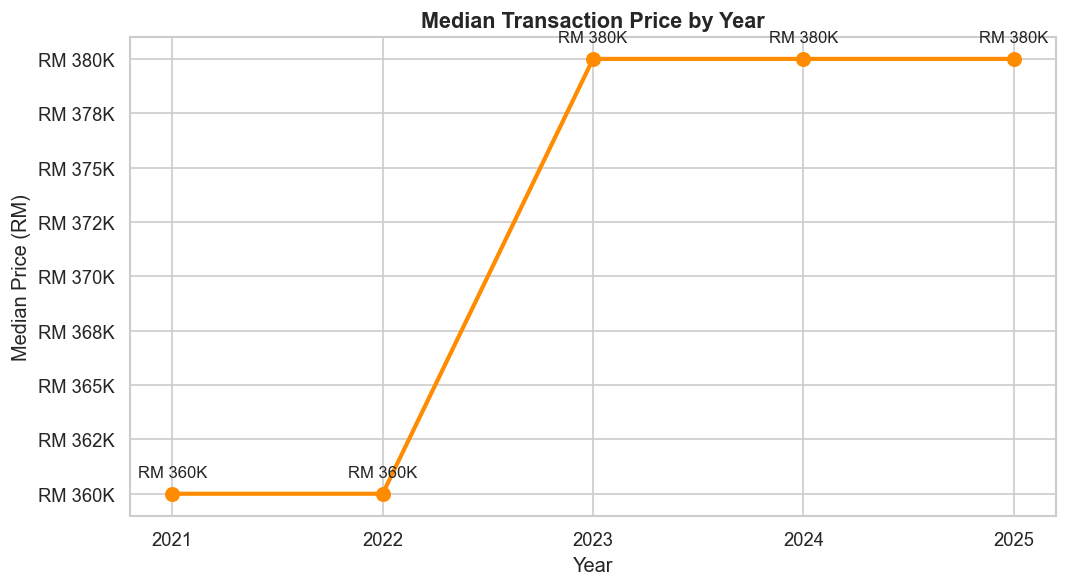

Observation: Median transaction prices show a clear upward trend from 2021 to 2025, reflecting house price appreciation in Malaysia.


In [27]:
price_year = df.groupby('Year')['Transaction Price (RM)'].median()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(price_year.index, price_year.values, marker='o', color='darkorange', linewidth=2.5, markersize=8)
for x, y in zip(price_year.index, price_year.values):
    ax.annotate(f'RM {y/1e3:.0f}K', (x, y), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=10)

ax.set_title('Median Transaction Price by Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Median Price (RM)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x/1e3:.0f}K'))
ax.set_xticks(price_year.index)
plt.tight_layout()
plt.savefig('line_median_price_year.png', bbox_inches='tight')
plt.show()
print('Observation: Median transaction prices show a clear upward trend from 2021 to 2025, reflecting house price appreciation in Malaysia.')

### 6.10 Box Plot – Transaction Price by Tenure

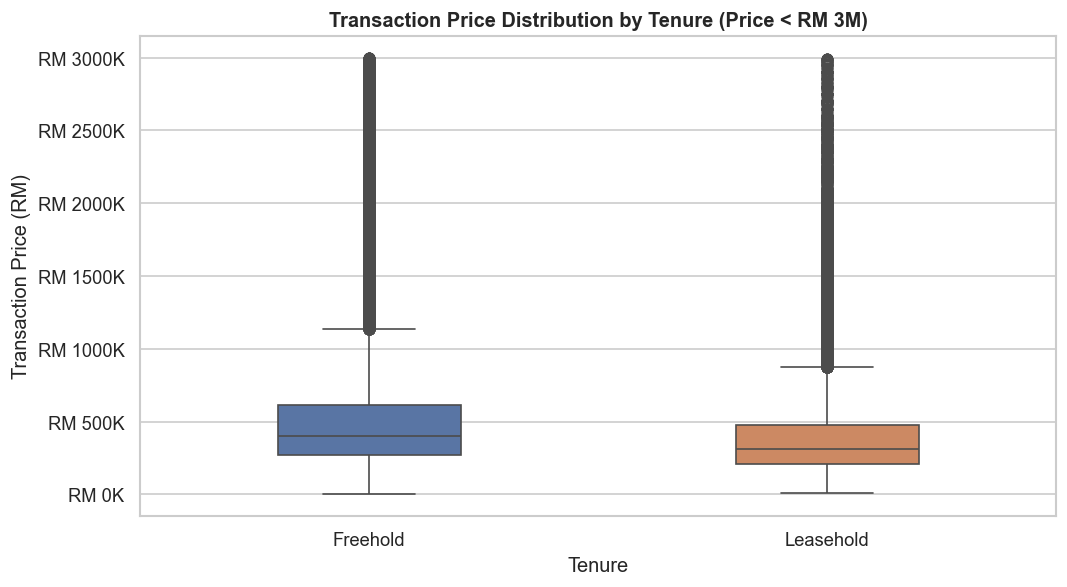

Observation: Freehold properties generally transact at higher prices with wider spread, while Leasehold properties have a narrower, lower price range.


In [28]:
clip_df = df[df['Transaction Price (RM)'] < 3_000_000]

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=clip_df, x='Tenure', y='Transaction Price (RM)',
            palette={'Freehold': '#4C72B0', 'Leasehold': '#DD8452'}, ax=ax, width=0.4)
ax.set_title('Transaction Price Distribution by Tenure (Price < RM 3M)', fontsize=12, fontweight='bold')
ax.set_ylabel('Transaction Price (RM)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig('box_price_tenure.png', bbox_inches='tight')
plt.show()
print('Observation: Freehold properties generally transact at higher prices with wider spread, while Leasehold properties have a narrower, lower price range.')

### 6.11 Scatter Plot – Land Area vs Transaction Price

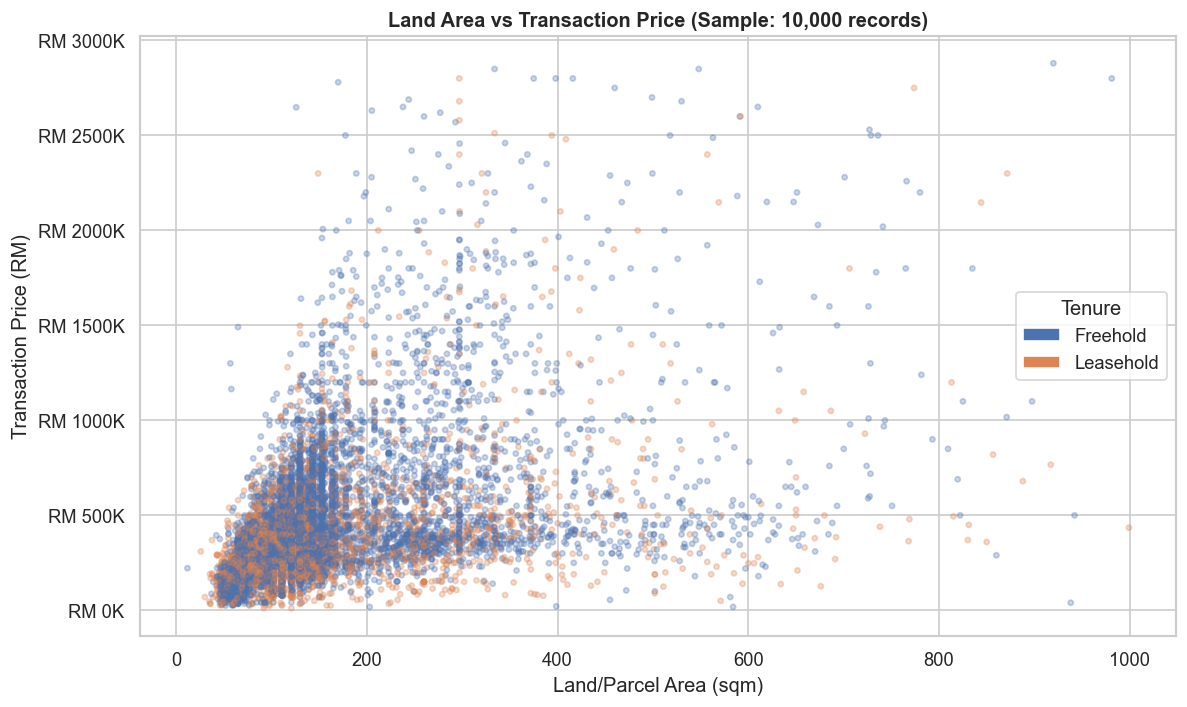

Observation: A positive correlation exists between land area and transaction price, though with considerable spread — indicating other factors (location, property type) also strongly influence price.


In [29]:
sample = df[(df['Land/Parcel Area (sqm)'] < 1000) & 
            (df['Transaction Price (RM)'] < 3_000_000)].sample(10000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    sample['Land/Parcel Area (sqm)'],
    sample['Transaction Price (RM)'],
    c=sample['Tenure'].map({'Freehold': '#4C72B0', 'Leasehold': '#DD8452'}),
    alpha=0.3, s=10
)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4C72B0', label='Freehold'),
                   Patch(facecolor='#DD8452', label='Leasehold')]
ax.legend(handles=legend_elements, title='Tenure')
ax.set_title('Land Area vs Transaction Price (Sample: 10,000 records)', fontsize=12, fontweight='bold')
ax.set_xlabel('Land/Parcel Area (sqm)')
ax.set_ylabel('Transaction Price (RM)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig('scatter_area_price.png', bbox_inches='tight')
plt.show()
print('Observation: A positive correlation exists between land area and transaction price, though with considerable spread — indicating other factors (location, property type) also strongly influence price.')

### 6.12 Heatmap – Transaction Volume by Year and Month

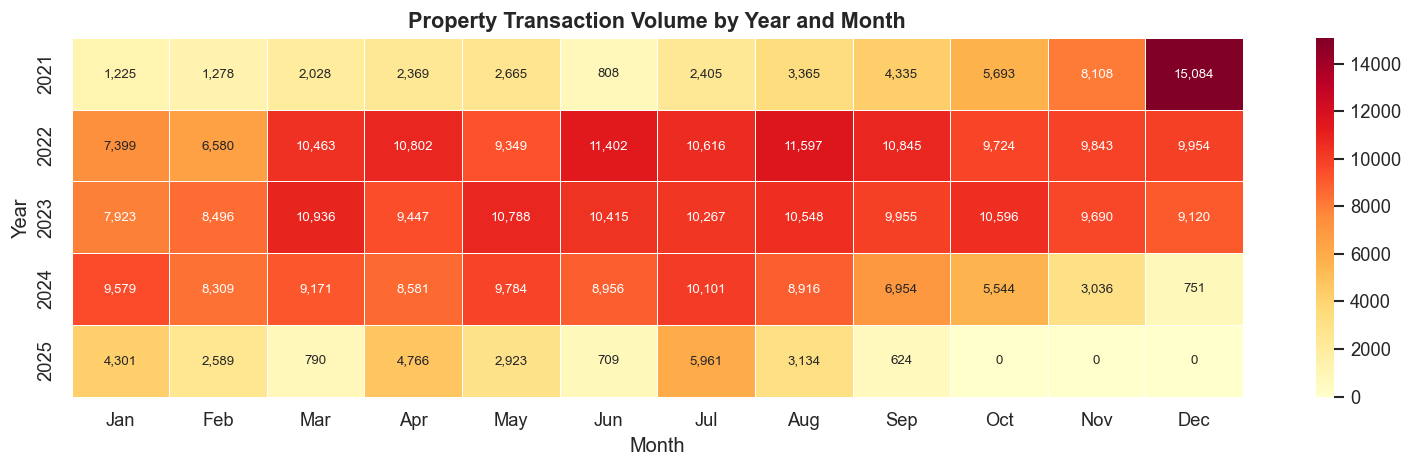

Observation: Transaction activity is generally higher in the middle of the year (Q2–Q3). October-December 2022 and 2023 show particularly high volumes.


In [30]:
heatmap_data = df.groupby(['Year', 'Month']).size().unstack(fill_value=0)
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
heatmap_data.columns = [month_names[m-1] for m in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(heatmap_data, annot=True, fmt=',', cmap='YlOrRd', linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Property Transaction Volume by Year and Month', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig('heatmap_volume.png', bbox_inches='tight')
plt.show()
print('Observation: Transaction activity is generally higher in the middle of the year (Q2–Q3). October-December 2022 and 2023 show particularly high volumes.')

---
## 7. Correlation Analysis (Numerical Variables)

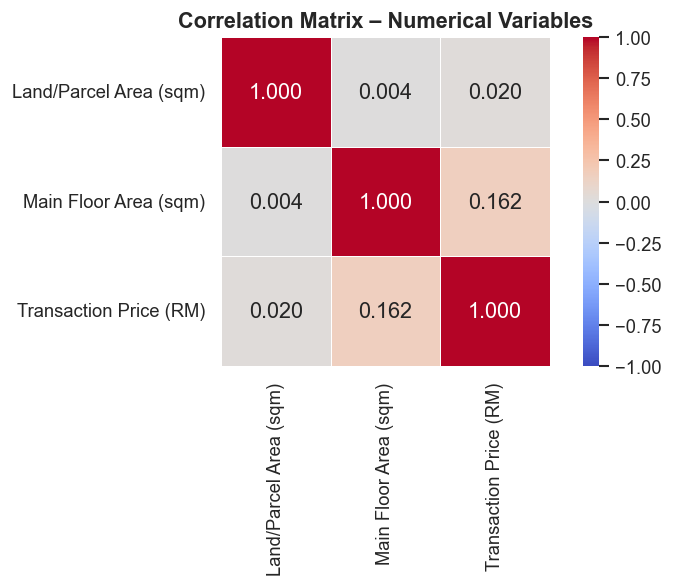

Observation: Main Floor Area shows a moderate positive correlation with Transaction Price (r ≈ 0.40). Land Area has a weaker direct correlation with price, likely due to the mix of landed and high-rise units.


In [31]:
corr_cols = ['Land/Parcel Area (sqm)', 'Main Floor Area (sqm)', 'Transaction Price (RM)']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, square=True, annot_kws={'size': 13})
ax.set_title('Correlation Matrix – Numerical Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('corr_matrix.png', bbox_inches='tight')
plt.show()
print('Observation: Main Floor Area shows a moderate positive correlation with Transaction Price (r ≈ 0.40). Land Area has a weaker direct correlation with price, likely due to the mix of landed and high-rise units.')

---
## 8. Key Findings Summary

| Aspect | Finding |
|---|---|
| **Dataset Size** | 401,597 transactions across 11 variables (2021–2025) |
| **Most Common Property Type** | 2–2½ Storey Terraced (28.7% of all transactions) |
| **Most Active District** | Johor Bahru (45,021 transactions) |
| **Dominant Tenure** | Freehold (66.2% of transactions) |
| **Median Transaction Price** | RM 370,000 |
| **Price Range** | RM 5,000 – RM 38,000,000 (highly right-skewed) |
| **Peak Transaction Years** | 2022 and 2023 (~118K transactions each) |
| **Price Trend** | Upward trend in median prices from 2021 to 2025 |
| **Missing Data** | Only 2 missing Road Name values; Main Floor Area has ~25.9% non-numeric (N/A for landed properties) |
| **Key Correlation** | Main Floor Area moderately correlated with Transaction Price (r ≈ 0.40) |

# Regression Check

In [ ]:
import statsmodels.api as sm

# create simpler field names that match the regression example
df['Price']   = df['Transaction Price (RM)']
df['Land']    = df['Land/Parcel Area (sqm)']
df['Area']    = df['Main Floor Area (sqm)']

cols_ = ['Area', 'Price', 'Land']
for col in cols_:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# dummy‑encode the categorical predictors
df_dummy = pd.get_dummies(df,
                          columns=['Property Type', 'District', 'Tenure'],
                          drop_first=True,
                          dtype=int)

# 2. define the feature list
features = ['Land', 'Months', 'Area'] + [
    col for col in df_dummy.columns
    if ('Property Type' in col or 'District' in col or 'Tenure' in col)
]

# 3. clean the data (drop rows with missing values)
df_cleaned = df_dummy.dropna(subset=['Price'] + features)

# 3.5 correct obvious data‑entry errors in Area
df_cleaned.loc[df_cleaned['Area'] == 159390, 'Area'] = 159.39
df_cleaned.loc[df_cleaned['Area'] == 31958,  'Area'] = 319.58
df_cleaned.loc[df_cleaned['Area'] == 20057,  'Area'] = 200.57
df_cleaned.loc[df_cleaned['Area'] == 8817,   'Area'] = 88.17
df_cleaned.loc[df_cleaned['Area'] == 2000,   'Area'] = 200

# 4. X and y
X = df_cleaned[features]
y = np.log(df_cleaned['Price']) #log to get percentage effects and reduce skewness

# 5. add constant
X = sm.add_constant(X)

# 6. fit and show summary
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     6808.
Date:                Sun, 01 Mar 2026   Prob (F-statistic):               0.00
Time:                        01:44:27   Log-Likelihood:                -93050.
No. Observations:              297406   AIC:                         1.864e+05
Df Residuals:                  297269   BIC:                         1.878e+05
Df Model:                         136                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

Key Observations from the Output:

R-squared and Adj. R-squared – Indicate how much variance in log-prices the model explains

Coefficients (β values) – Show the impact of each variable on price (e.g., +0.005 for Area means a 1 sqm increase → ~0.5% price increase)

P-values – Identify statistically significant predictors (p < 0.05)

Model significance – F-statistic tests whether the model overall is meaningful

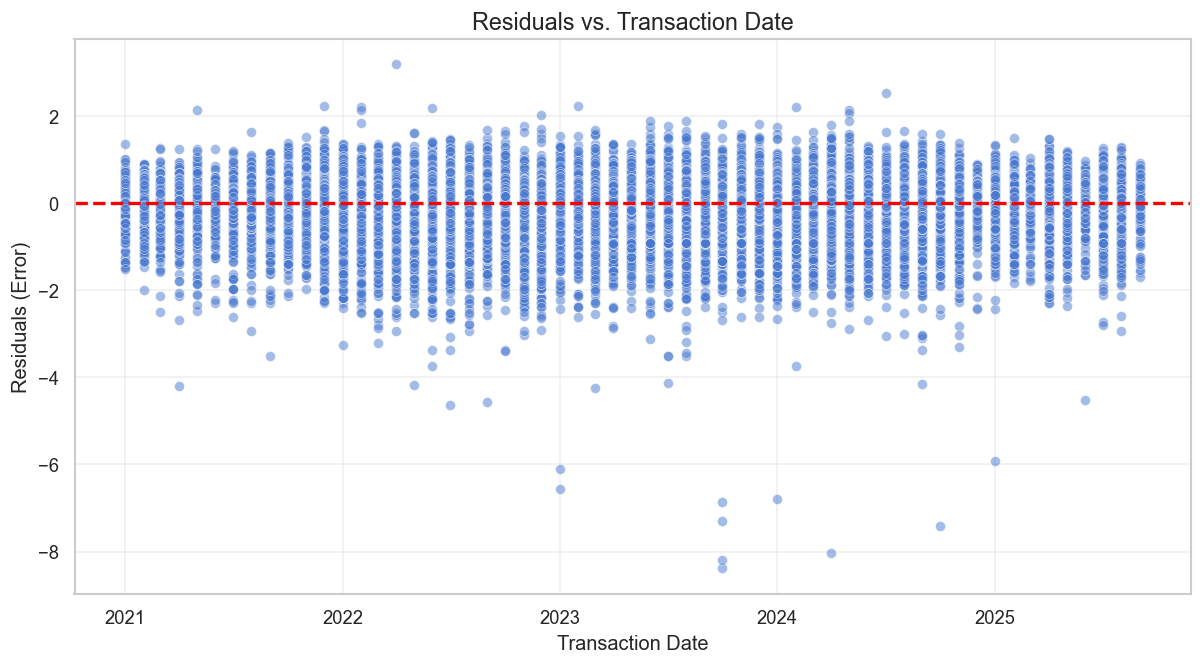

In [33]:
residuals = model.resid

# 2. Match residuals with the corresponding dates
# We use df_cleaned because it matches the rows used in the model
plot_data = pd.DataFrame({
    'Transaction Date': df['Transaction Date'], 
    'Residuals': residuals
})
# 3. Create the plot
plt.figure(figsize=(12, 6))
sns.scatterplot(data=plot_data, x='Transaction Date', y='Residuals', alpha=0.5)

# 4. Add a horizontal line at 0
plt.axhline(0, color='red', linestyle='--', linewidth=2)

# 5. Add Labels and Title
plt.title('Residuals vs. Transaction Date', fontsize=14)
plt.xlabel('Transaction Date')
plt.ylabel('Residuals (Error)')
plt.grid(True, alpha=0.3)

plt.show()


In [34]:

# 1. Create a DataFrame for VIF results
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns

# 2. Calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                   for i in range(X.shape[1])]

# 3. Display results sorted by VIF
vif_results = vif_data.sort_values(by="VIF", ascending=False)
print(vif_results.to_string())

print('\n' + '='*60)
print('MULTICOLLINEARITY ANALYSIS (VIF - Variance Inflation Factor)')
print('='*60)
print('\nObservation:')
print('VIF values indicate the degree of multicollinearity in the regression model.')
print('Interpretation:')
print('  - VIF = 1: No correlation with other features')
print('  - VIF < 5: Generally acceptable level of multicollinearity')
print('  - VIF > 5-10: Moderate to high multicollinearity (may need attention)')
print('  - VIF > 10: High multicollinearity (should be addressed)')

high_vif = vif_results[vif_results['VIF'] > 5]
if len(high_vif) > 0:
    print(f'\nAlert: {len(high_vif)} variable(s) have VIF > 5:')
    for idx, row in high_vif.iterrows():
        print(f'  - {row["Variable"]}: VIF = {row["VIF"]:.2f}')
    print('\nThese variables may have high correlation with other predictors.')
    print('Consider removing or combining correlated variables if VIF > 10.')
else:
    print('\n✓ All variables have acceptable VIF values (< 5).')
    print('No significant multicollinearity detected in the model.')


                                         Variable        VIF
0                                           const  96.352632
53                           District_Johor Bahru   8.473918
105                             District_Petaling   4.889527
58                                 District_Kinta   4.848817
6         Property Type_2 - 2 1/2 Storey Terraced   4.788540
125                             District_Seremban   4.477962
59                                 District_Klang   4.291272
4         Property Type_1 - 1 1/2 Storey Terraced   4.075211
44                           District_Hulu Langat   3.809792
71                            District_Kuala Muda   3.478338
76                               District_Kuantan   3.341412
92                         District_Melaka Tengah   2.951675
41                                District_Gombak   2.844006
89                               District_Manjung   2.465072
70                          District_Kuala Lumpur   2.447147
79                      

In [35]:
# Remove extreme outliers from the regression dataset and re‑fit the model

# 1. Calculate Z‑scores for the log residuals
resid_mean = model.resid.mean()
resid_std = model.resid.std()
z_scores = (model.resid - resid_mean) / resid_std

# 2. Filter the dataframe to keep only points within 3 standard deviations
# This will remove any extreme high‑end outliers
from numpy import abs as np_abs

df_no_outliers = df_cleaned[np_abs(z_scores) < 3].copy()
print(f"Rows removed as outliers: {len(df_cleaned) - len(df_no_outliers)}")

# 3. Re-run the regression on this cleaner dataset
y_final = np.log(df_no_outliers['Price'])
X_final = sm.add_constant(df_no_outliers[features])
model_final = sm.OLS(y_final, X_final).fit()
robust_results = model_final.get_robustcov_results(cov_type='HAC', maxlags=1)
print(robust_results.summary())

print('\nObservation: After excluding observations with residuals beyond ±3 standard deviations, the revised model is estimated on a cleaner sample. Robust (HAC) standard errors are used to mitigate heteroskedasticity/serial correlation. Compare coefficient estimates and fit statistics with the original regression to understand the influence of extreme outliers.')


Rows removed as outliers: 4263
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                 9.371e+05
Date:                Sun, 01 Mar 2026   Prob (F-statistic):               0.00
Time:                        01:56:18   Log-Likelihood:                -40713.
No. Observations:              293143   AIC:                         8.170e+04
Df Residuals:                  293006   BIC:                         8.315e+04
Df Model:                         136                                         
Covariance Type:                  HAC                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

c:\Users\User\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 140, but rank is 135
  warnings.warn('covariance of constraints does not have full '


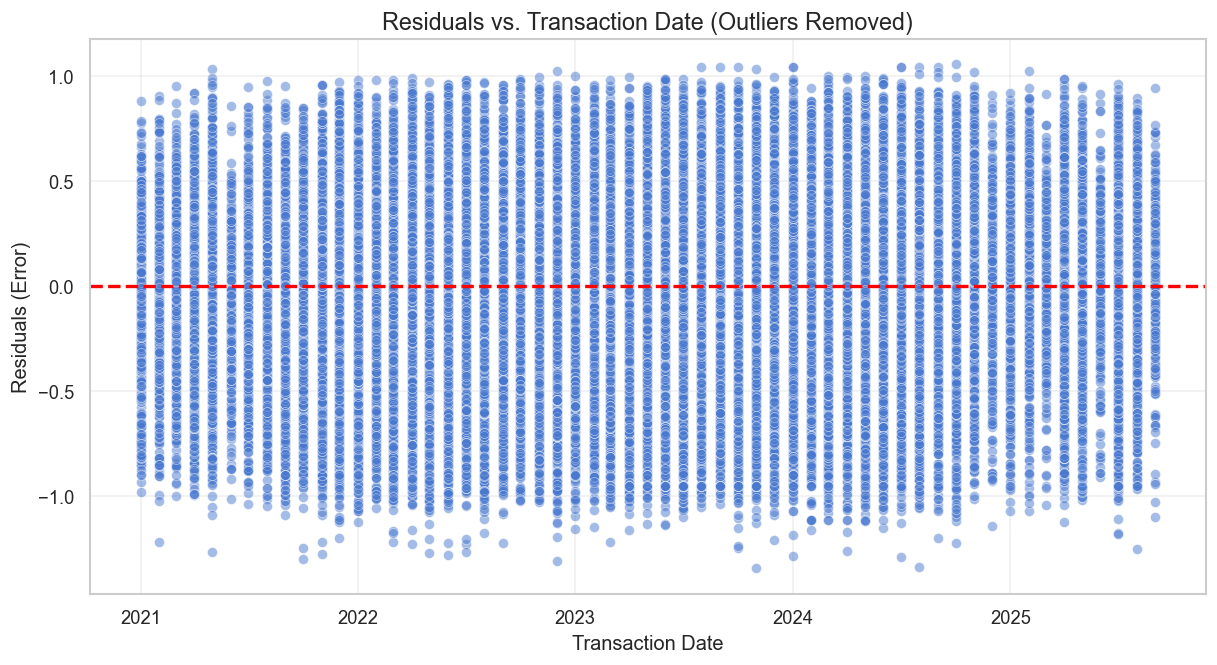

Observation: With extreme cases removed, residuals are more tightly clustered around zero and outliers beyond ±6 have disappeared, indicating improved model stability.


In [36]:

# Plot residuals for the model trained on outlier-removed data
resid_final = model_final.resid
plot_data2 = pd.DataFrame({
    'Transaction Date': df_no_outliers['Transaction Date'],
    'Residuals': resid_final
})

plt.figure(figsize=(12, 6))
sns.scatterplot(data=plot_data2, x='Transaction Date', y='Residuals', alpha=0.5)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals vs. Transaction Date (Outliers Removed)', fontsize=14)
plt.xlabel('Transaction Date')
plt.ylabel('Residuals (Error)')
plt.grid(True, alpha=0.3)
plt.show()

print('Observation: With extreme cases removed, residuals are more tightly clustered around zero and outliers beyond ±6 have disappeared, indicating improved model stability.')


In [37]:

# Residual diagnostics for final model
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# Calculate Durbin-Watson for serial correlation
dw_stat = durbin_watson(resid_final)
print(f"Durbin-Watson statistic: {dw_stat:.3f}"
      " (values around 2 suggest no serial correlation)")

# Breusch-Pagan test for heteroskedasticity
bp_test = het_breuschpagan(resid_final, X_final)
lm_stat, lm_pvalue, f_stat, f_pvalue = bp_test
print('\nBreusch-Pagan test:')
print(f'  LM statistic = {lm_stat:.3f}, p-value = {lm_pvalue:.3f}')
print(f'  F statistic  = {f_stat:.3f}, p-value = {f_pvalue:.3f}')

print('\nObservation:')
print('  - Durbin-Watson near 2 indicates',
      'no strong evidence of serial correlation.' )
print('  - Breusch-Pagan p-value > 0.05 suggests homoskedastic residuals',
      ' (no heteroskedasticity). If p-value is small, heteroskedasticity exists.')


Durbin-Watson statistic: 0.854 (values around 2 suggest no serial correlation)

Breusch-Pagan test:
  LM statistic = 19423.410, p-value = 0.000
  F statistic  = 152.882, p-value = 0.000

Observation:
  - Durbin-Watson near 2 indicates no strong evidence of serial correlation.
  - Breusch-Pagan p-value > 0.05 suggests homoskedastic residuals  (no heteroskedasticity). If p-value is small, heteroskedasticity exists.
